# MNIST Database

In [4]:
! pip install keras


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [5]:
import os
os.environ["KERAS_BACKEND"] = "torch"

# keras
import keras
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten
from keras.layers import Conv2D, MaxPooling2D
from keras import backend as K




In [6]:
# Tensorflow approach
import keras
from keras import layers

## Neuron

In [7]:
# single neuron
neuron = layers.Dense(1)

In [8]:
# a dense layer with 4 neurons
layers.Dense(4)

<Dense name=dense_1, built=False>

## Perceptron

`Input-> Weighted Sum-> Activation -> Binary Output`

In [9]:
model = keras.Sequential([
    layers.Dense(1, activation='sigmoid')
])

In [10]:
# Compile the model for Classification
model.compile(
    optimizer=keras.optimizers.SGD(learning_rate=0.01),
    loss='binary_crossentropy',
    metrics=['accuracy'],
)

In [11]:
# data for model
import numpy as np
data = np.random.random((1000, 784))
labels = np.random.randint(2, size=(1000, 1))
print(data[:5])
print(labels[:5])
print(data.shape)
print(labels.shape)

[[0.46189456 0.30795521 0.80113879 ... 0.38333145 0.69955384 0.54926911]
 [0.60285382 0.64934345 0.74281207 ... 0.90809234 0.56823427 0.8025121 ]
 [0.64234983 0.03076457 0.09385436 ... 0.22812713 0.83418469 0.37896022]
 [0.43248403 0.1670633  0.68845937 ... 0.73042016 0.69534832 0.35539893]
 [0.17488984 0.0023842  0.78101704 ... 0.56463967 0.54122949 0.38924871]]
[[0]
 [0]
 [1]
 [1]
 [1]]
(1000, 784)
(1000, 1)


In [12]:
history = model.fit(data, labels, epochs=100, validation_split=0.2)

Epoch 1/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4900 - loss: 0.7197 - val_accuracy: 0.4750 - val_loss: 0.7200
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4900 - loss: 0.7071 - val_accuracy: 0.4750 - val_loss: 0.7205
Epoch 3/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5113 - loss: 0.7033 - val_accuracy: 0.4800 - val_loss: 0.7202
Epoch 4/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5375 - loss: 0.6985 - val_accuracy: 0.4500 - val_loss: 0.7209
Epoch 5/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5350 - loss: 0.6962 - val_accuracy: 0.4950 - val_loss: 0.7233
Epoch 6/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5412 - loss: 0.6880 - val_accuracy: 0.4650 - val_loss: 0.7236
Epoch 7/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5550 - loss: 0.6843 - val_accuracy: 0.4550 - val_loss: 0.7199
Epoch 8/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5487 - loss: 0.6802 - val_accuracy: 0.4450 - v

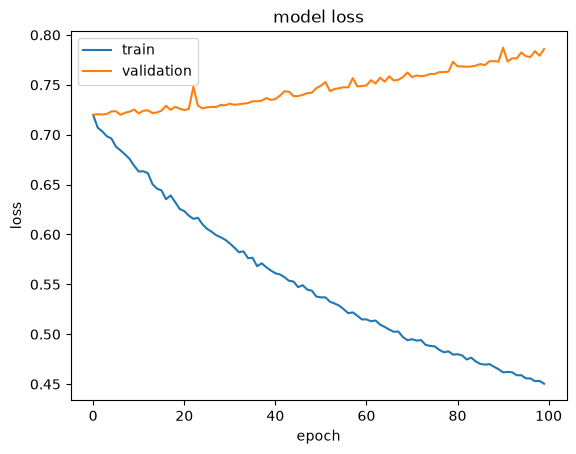

In [13]:
# draw the train and validation loss to epoch graph

import matplotlib.pyplot as plt
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()


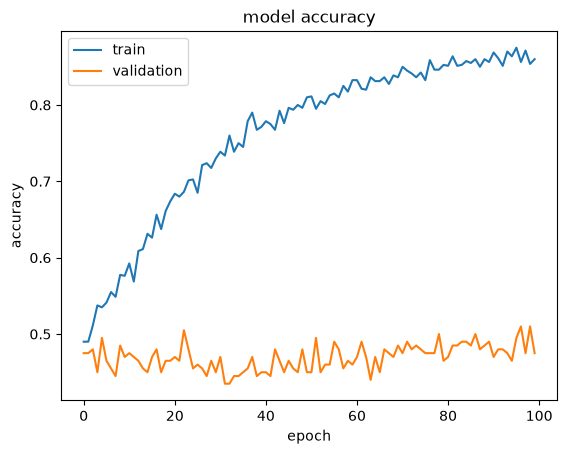

In [14]:
# plot the accuracy for train, validation
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

## 2 activation function- multi layer model

In [15]:
# shallow model
model = keras.Sequential([
    layers.Dense(4, activation='relu'), # Hidden
    layers.Dense(1, activation='sigmoid') # output
])

In [16]:
# loss = binary_crossentropy
model.compile(
    optimizer=keras.optimizers.SGD(learning_rate=0.01),
    loss='binary_crossentropy',
    metrics=['accuracy'],
)


In [17]:
# summary of model
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [18]:
# train this compile
history = model.fit(data, labels, epochs=100, validation_split=0.2, batch_size=32)

Epoch 1/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4925 - loss: 0.7038 - val_accuracy: 0.4900 - val_loss: 0.6946
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4975 - loss: 0.6957 - val_accuracy: 0.4900 - val_loss: 0.6931
Epoch 3/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5050 - loss: 0.6944 - val_accuracy: 0.4900 - val_loss: 0.6929
Epoch 4/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5013 - loss: 0.6941 - val_accuracy: 0.5000 - val_loss: 0.6927
Epoch 5/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5075 - loss: 0.6938 - val_accuracy: 0.4550 - val_loss: 0.6926
Epoch 6/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4812 - loss: 0.6936 - val_accuracy: 0.4600 - val_loss: 0.6925
Epoch 7/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4900 - loss: 0.6935 - val_accuracy: 0.4900 - val_loss: 0.6924
Epoch 8/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4913 - loss: 0.6934 - val_accuracy: 0.4950 - v

In [19]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (32, 4)                │         3,140 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (32, 1)                │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,147 (12.29 KB)

 Trainable params: 3,145 (12.29 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (8.00 B)

In [20]:
# small data
import numpy as np

# input for 4 features
X = np.array([[2,3,1,4]])

# Weights
W1 = np.array([
    [1,2,1],
    [2,1,3],
    [1,1,2],
    [2,3,1]
])

# Bias

b1 = np.array([1,2,1])

# calculate 1st layer
Z1 =np.dot(X,W1) + b1

print(Z1)


[[18 22 18]]


In [21]:
# second layer
W2 = np.array([
    [1,2],
    [2,1],
    [3,1]
])

b2= np.array([1,2])

Z2 = np.dot(Z1,W2) + b2
print(Z2)

[[117  78]]


In [22]:
# visualize both layers of nupy based layers

print(f"Input X: {X}")
print(f"First layer output (Z1): {Z1}")
print(f"Second layer output (Z2): {Z2}")

Input X: [[2 3 1 4]]
First layer output (Z1): [[18 22 18]]
Second layer output (Z2): [[117  78]]


In [23]:
# do with keras
model = keras.Sequential([
    layers.Input(shape=(4,)),
    layers.Dense(3, activation='relu'),
    layers.Dense(2, activation='sigmoid')
])

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 3)              │            15 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 2)              │             8 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23 (92.00 B)

 Trainable params: 23 (92.00 B)

 Non-trainable params: 0 (0.00 B)

In [24]:
# layer wise understanding
for layer in model.layers:

    print("Layer name: ", layer.name)
    weights, bias = layer.get_weights()
    print("Layer weights: ", weights)
    print("Layer bias: ", bias)
    print("Layer input shape: ", weights.shape)
    print("Layer output shape: ", bias.shape)

    print("Layer output: ", layer.output)
    print("Layer input: ", layer.input)


Layer name:  dense_5
Layer weights:  [[ 0.6764829  -0.7338277   0.4897704 ]
 [ 0.2271812   0.48230958  0.23462677]
 [-0.6368774   0.89150524  0.8552731 ]
 [ 0.72068703 -0.80686826 -0.09521967]]
Layer bias:  [0. 0. 0.]
Layer input shape:  (4, 3)
Layer output shape:  (3,)
Layer output:  <KerasTensor shape=(None, 3), dtype=float32, sparse=False, ragged=False, name=keras_tensor_18>
Layer input:  <KerasTensor shape=(None, 4), dtype=float32, sparse=False, ragged=False, name=keras_tensor_17>
Layer name:  dense_6
Layer weights:  [[-0.46475834 -0.6253821 ]
 [-1.0253922   0.39772654]
 [-0.23443782 -0.92089355]]
Layer bias:  [0. 0.]
Layer input shape:  (3, 2)
Layer output shape:  (2,)
Layer output:  <KerasTensor shape=(None, 2), dtype=float32, sparse=False, ragged=False, name=keras_tensor_19>
Layer input:  <KerasTensor shape=(None, 3), dtype=float32, sparse=False, ragged=False, name=keras_tensor_18>


# MNIST problem
<img src = "https://upload.wikimedia.org/wikipedia/commons/b/b1/MNIST_dataset_example.png">



In [25]:
# load the mnist dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
assert x_train.shape == (60000, 28, 28)
assert x_test.shape == (10000, 28, 28)
assert y_train.shape == (60000,)
assert y_test.shape == (10000,)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


In [26]:
# plot one of the image
x_train[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  

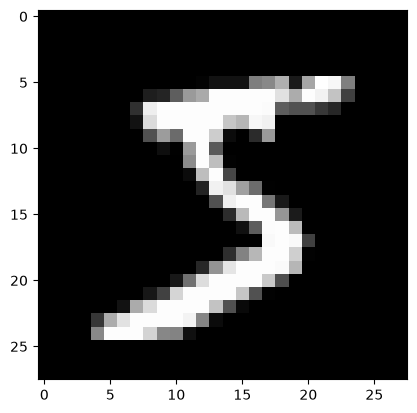

In [27]:
# matrix of the image
import matplotlib.pyplot as plt
plt.imshow(x_train[0], cmap='gray')
plt.show()

In [28]:
# matrix
print(x_train[0])

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3  18  18  18 126 136
  175  26 166 255 247 127   0   0   0   0]
 [  0   0   0   0   0   0   0   0  30  36  94 154 170 253 253 253 253 253
  225 172 253 242 195  64   0   0   0   0]
 [  0   0   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251
   93  82  82  56  39   0   0   0   0   0]
 [  0   0   0   0   0   0   0  18 219 253 253 253 253 253 198 18

In [29]:
# train a svm model for this data
from sklearn.svm import SVC

svm_model = SVC()
svm_model.fit(x_train.reshape(60000, 28*28), y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [30]:
# prediction
y_pred = svm_model.predict(x_test.reshape(10000, 28*28))

# accuracy
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.9792

In [31]:
# ann model
import keras
from keras import layers
model = keras.Sequential([
    layers.Input(shape=(28,28)),
    layers.Flatten(),
    layers.Dense(16, activation='relu'),
    layers.Dense(8, activation='relu'),
    layers.Dense(10, activation='softmax')
])

In [32]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 16)             │        12,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │            90 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,786 (49.95 KB)

 Trainable params: 12,786 (49.95 KB)

 Non-trainable params: 0 (0.00 B)

In [33]:
# compile
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

In [34]:
# fit the data
history = model.fit(x_train, y_train, epochs=100, validation_split=0.2)

Epoch 1/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.1261 - loss: 2.3931 - val_accuracy: 0.1996 - val_loss: 2.0194
Epoch 2/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.2146 - loss: 1.9060 - val_accuracy: 0.2485 - val_loss: 1.8107
Epoch 3/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.2592 - loss: 1.7967 - val_accuracy: 0.2950 - val_loss: 1.7325
Epoch 4/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.3481 - loss: 1.6766 - val_accuracy: 0.3861 - val_loss: 1.5238
Epoch 5/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.4559 - loss: 1.4431 - val_accuracy: 0.5041 - val_loss: 1.2894
Epoch 6/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.5214 - loss: 1.2613 - val_accuracy: 0.5529 - val_loss: 1.1955
Epoch 7/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.5856 - loss: 1.1413 - val_accuracy: 0.6199 - val_loss: 1.0443
Epoch 8/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.6377 - loss: 

In [35]:
# model test
model.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9139 - loss: 0.3594


[0.3594473600387573, 0.9139000177383423]

In [36]:
# print train,evaluation, and test accuarcy and loss
print(f"Train accuracy: {history.history['accuracy'][-1]}")
print(f"Train loss: {history.history['loss'][-1]}")
print(f"Validation accuracy: {history.history['val_accuracy'][-1]}")
print(f"Validation loss: {history.history['val_loss'][-1]}")
print(f"Test accuracy: {model.evaluate(x_test, y_test)[1]}")
print(f"Test loss: {model.evaluate(x_test, y_test)[0]}")


Train accuracy: 0.9390624761581421
Train loss: 0.20662620663642883
Validation accuracy: 0.9170833230018616
Validation loss: 0.34911108016967773
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9139 - loss: 0.3594
Test accuracy: 0.9139000177383423
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9139 - loss: 0.3594
Test loss: 0.3594473600387573


In [37]:
# best results
print(f"Best train accuracy: {max(history.history['accuracy'])}")
print(f"Best train loss: {min(history.history['loss'])}")

Best train accuracy: 0.9408541917800903
Best train loss: 0.2043025642633438
